<a href="https://colab.research.google.com/github/18chithraja/PrivacyLens/blob/main/PrivacyLens_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Welcome to PrivacyLens!")
print("My first AI project has started.")

Welcome to PrivacyLens!
My first AI project has started.


# PrivacyLens

### Reflection-Aware Visual Privacy Risk Detection for Smartphone Photography

PrivacyLens is an AI-based computer vision project that detects possible privacy-sensitive content in smartphone photographs, including:

- Faces
- Mobile/laptop screens
- Documents
- Personal information
- Text visible through reflections

The project uses Python, OpenCV, YOLO, OCR, and Google Colab.

In [1]:
print("PrivacyLens development started successfully!")

PrivacyLens development started successfully!


In [2]:
!pip install opencv-python matplotlib pillow easyocr ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 31.8 MB/s eta 0:00:00


In [3]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import easyocr
from ultralytics import YOLO

print("All libraries imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
All libraries imported successfully!


In [4]:
print("PrivacyLens development started successfully!")
print("Project: Reflection-Aware Visual Privacy Risk Detection")

PrivacyLens development started successfully!
Project: Reflection-Aware Visual Privacy Risk Detection


In [5]:
!pip install -q opencv-python matplotlib pillow easyocr ultralytics

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
import easyocr

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
project_folder = "/content/PrivacyLens"

folders = [
    "images",
    "results",
    "models",
    "notebooks"
]

for folder in folders:
    folder_path = os.path.join(project_folder, folder)
    os.makedirs(folder_path, exist_ok=True)

print("Project folders created:")
print(project_folder)

Project folders created:
/content/PrivacyLens


In [12]:
from google.colab import files

uploaded = files.upload()

image_name = list(uploaded.keys())[0]
image_path = image_name

print("Uploaded image:", image_name)

Saving Gemini_Generated_Image_x6jsx0x6jsx0x6js.png to Gemini_Generated_Image_x6jsx0x6jsx0x6js.png
Uploaded image: Gemini_Generated_Image_x6jsx0x6jsx0x6js.png


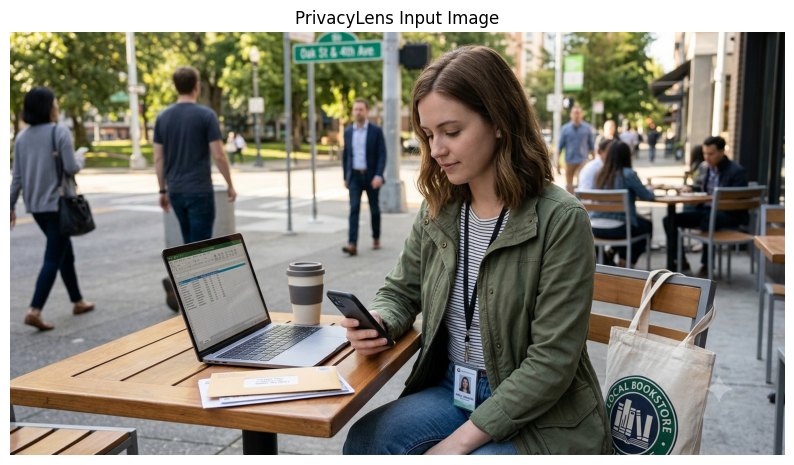

In [13]:
image = cv2.imread(image_path)

if image is None:
    print("Image could not be opened.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("PrivacyLens Input Image")
    plt.show()

In [14]:
if image is not None:
    height, width, channels = image.shape

    print("Image width:", width)
    print("Image height:", height)
    print("Number of channels:", channels)

Image width: 1408
Image height: 768
Number of channels: 3


In [15]:
if image is not None:
    height, width, channels = image.shape

    print("Image width:", width)
    print("Image height:", height)
    print("Number of channels:", channels)

Image width: 1408
Image height: 768
Number of channels: 3


In [16]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred_image = cv2.GaussianBlur(
    gray_image,
    (5, 5),
    0
)

print("Image preprocessing completed.")

Image preprocessing completed.


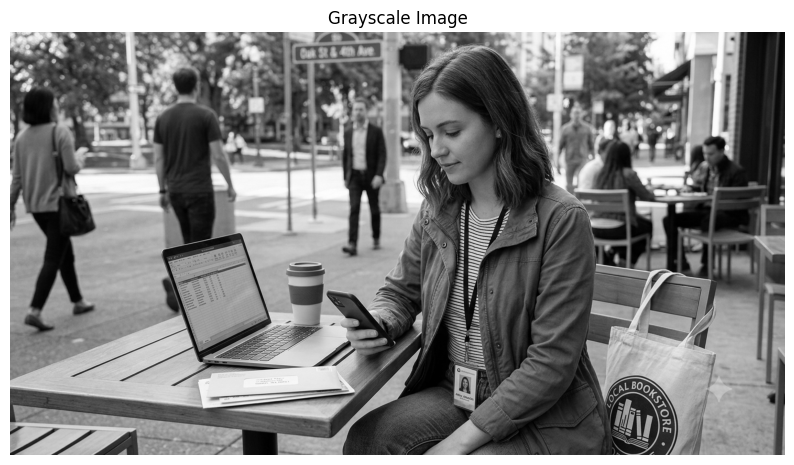

In [17]:
plt.figure(figsize=(10, 6))
plt.imshow(gray_image, cmap="gray")
plt.axis("off")
plt.title("Grayscale Image")
plt.show()

In [18]:
reader = easyocr.Reader(
    ["en"],
    gpu=True
)

print("OCR reader initialized.")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR reader initialized.


In [19]:
ocr_results = reader.readtext(image_path)

print("OCR detection completed.")
print("Number of detected text regions:", len(ocr_results))

for result in ocr_results:
    bounding_box, detected_text, confidence = result

    print("Text:", detected_text)
    print("Confidence:", round(confidence, 3))
    print("-" * 40)


OCR detection completed.
Number of detected text regions: 2
Text: ))
Confidence: 0.642
----------------------------------------
Text: CAL
Confidence: 1.0
----------------------------------------


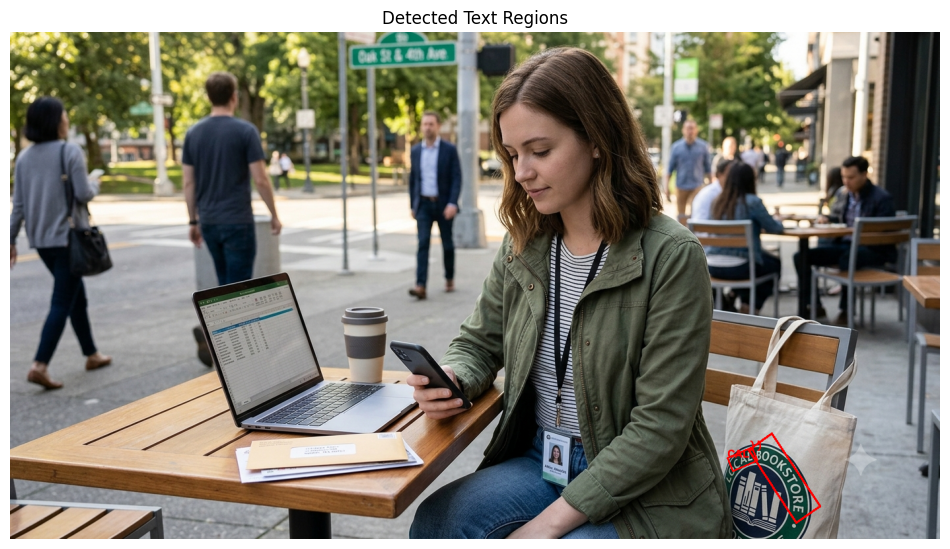

In [20]:
annotated_image = image_rgb.copy()

for result in ocr_results:
    bounding_box, detected_text, confidence = result

    points = np.array(bounding_box).astype(int)

    cv2.polylines(
        annotated_image,
        [points],
        isClosed=True,
        color=(255, 0, 0),
        thickness=2
    )

    text_position = tuple(points[0])

    cv2.putText(
        annotated_image,
        detected_text,
        text_position,
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("Detected Text Regions")
plt.show()

In [21]:
result_path = "/content/PrivacyLens/results/ocr_result.jpg"

cv2.imwrite(
    result_path,
    cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)
)

print("Result saved at:")
print(result_path)

Result saved at:
/content/PrivacyLens/results/ocr_result.jpg


In [22]:
number_of_text_regions = len(ocr_results)

if number_of_text_regions == 0:
    risk_score = 0
    risk_level = "Low"
elif number_of_text_regions <= 3:
    risk_score = 40
    risk_level = "Medium"
else:
    risk_score = 80
    risk_level = "High"

print("Privacy risk score:", risk_score, "/ 100")
print("Privacy risk level:", risk_level)

Privacy risk score: 40 / 100
Privacy risk level: Medium


In [23]:
number_of_text_regions = len(ocr_results)

if number_of_text_regions == 0:
    risk_score = 0
    risk_level = "Low"
elif number_of_text_regions <= 3:
    risk_score = 40
    risk_level = "Medium"
else:
    risk_score = 80
    risk_level = "High"

print("Privacy risk score:", risk_score, "/ 100")
print("Privacy risk level:", risk_level)

Privacy risk score: 40 / 100
Privacy risk level: Medium


In [24]:
print("====================================")
print("PrivacyLens Project Status")
print("====================================")
print("Image upload: Completed")
print("Image preprocessing: Completed")
print("OCR text detection: Completed")
print("Text region visualization: Completed")
print("Basic risk scoring: Completed")
print("Next step: Face, screen, document, and reflection detection")

PrivacyLens Project Status
Image upload: Completed
Image preprocessing: Completed
OCR text detection: Completed
Text region visualization: Completed
Basic risk scoring: Completed
Next step: Face, screen, document, and reflection detection
